In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/1

In [1]:
!pip install shap

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyCaret imports
from pycaret.classification import *

import shap

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
#dataset from Google Drive
csv_path = "/content/drive/My Drive/DB_CHD-1.csv"
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
print(f"Features: {df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (4240, 16)
Features: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

First 5 rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:

print("DATASET OVERVIEW")
print("="*60)
df.info()

print("\nDESCRIPTIVE STATISTICS")
print("="*60)
print(df.describe())

print("\nTARGET VARIABLE DISTRIBUTION")
print("="*60)
print(df['TenYearCHD'].value_counts())
print(f"CHD Rate: {df['TenYearCHD'].mean():.2%}")

#missing values if
print("\nMISSING VALUES")
print("="*40)
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    print(missing_data)
else:
    print("No missing values found!")

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1

Key Observations

CHD Rate: 15.19% (644/4240) - imbalanced dataset
Missing values: most abundant glucose (388), education (105), cigsPerDay (29)...
Dataset size: 4240 records large enough for machine learning

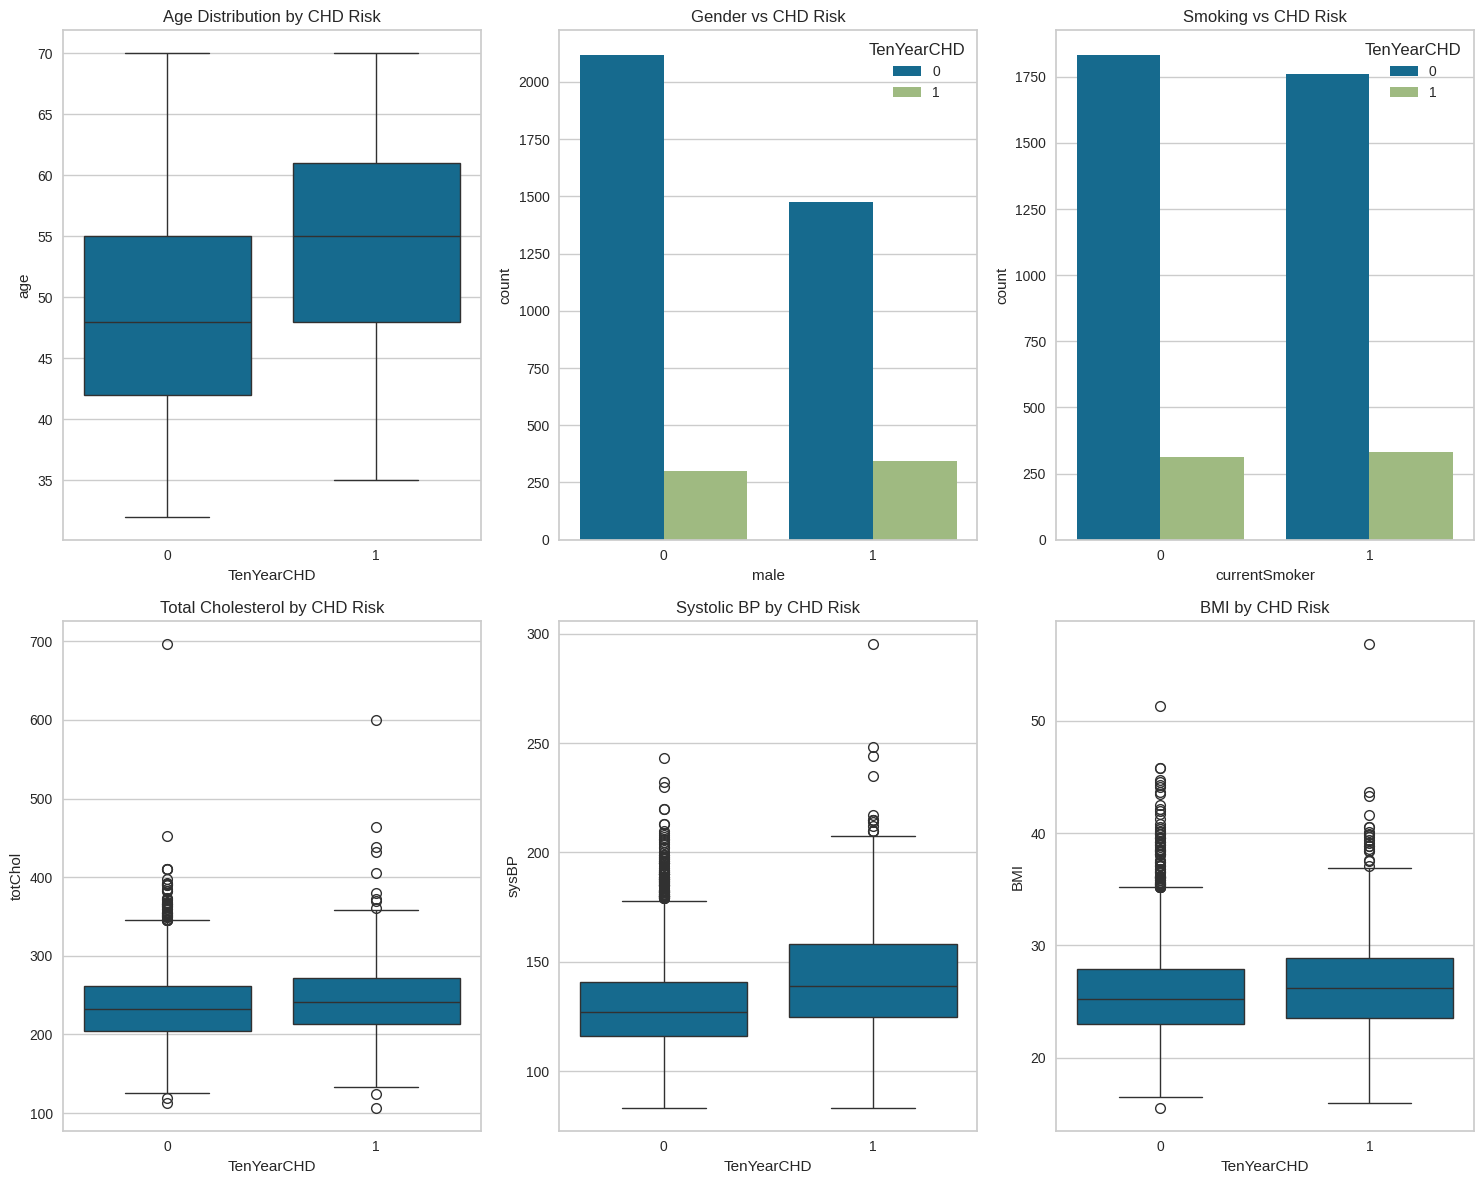

In [5]:
# visualizations
plt.figure(figsize=(15, 12))

# Age
plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='TenYearCHD', y='age')
plt.title('Age Distribution by CHD Risk')

# Gender
plt.subplot(2, 3, 2)
sns.countplot(data=df, x='male', hue='TenYearCHD')
plt.title('Gender vs CHD Risk')

# Smoking vs CHD
plt.subplot(2, 3, 3)
sns.countplot(data=df, x='currentSmoker', hue='TenYearCHD')
plt.title('Smoking vs CHD Risk')

# Cholesterol
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='TenYearCHD', y='totChol')
plt.title('Total Cholesterol by CHD Risk')

# Blood
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='TenYearCHD', y='sysBP')
plt.title('Systolic BP by CHD Risk')

# BMI
plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='TenYearCHD', y='BMI')
plt.title('BMI by CHD Risk')

plt.tight_layout()
plt.show()

Key observations:

Age: CHD patients were older (median ~50 vs. ~43)
Gender: Men had higher risk than women
Smoking: Smokers had higher risk
Cholesterol: CHD patients had slightly higher cholesterol
Systolic blood pressure: CHD patients had significantly higher blood pressure
BMI: Similar between groups

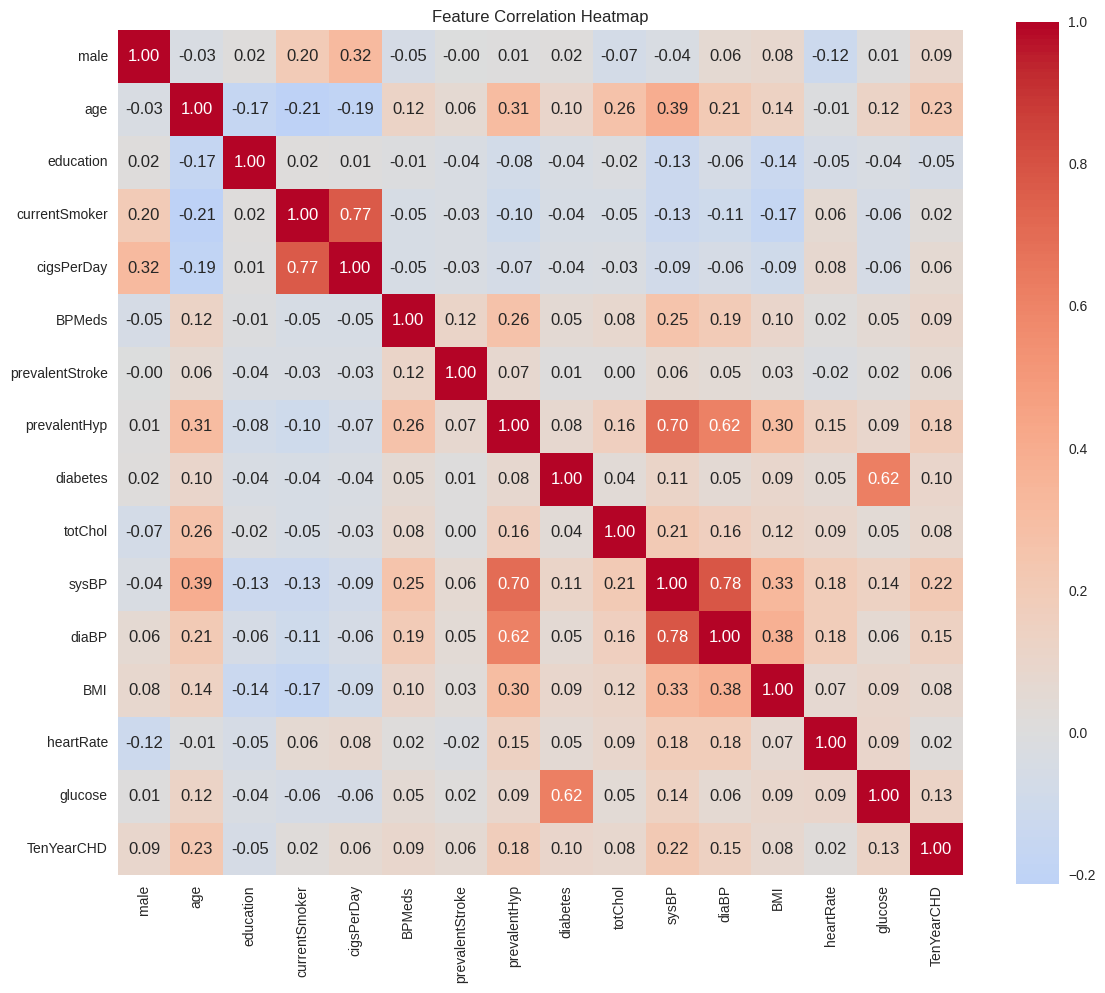


STARTING PYCARET MODELING


In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# PyCaret modeling
print("\nSTARTING PYCARET MODELING")
print("="*50)

Strong correlations:

sysBP & diaBP: 0.78 (expected - blood pressure measures)
prevalentHyp & sysBP: 0.70 (hypertension with systolic BP)
diabetes & glucose: 0.62 (expected correlation)

Target correlations with TenYearCHD:

age: 0.23 (strongest predictor)
sysBP: 0.22
prevalentHyp: 0.18

In [9]:
# Basic setup
clf = setup(data=df,
           target='TenYearCHD',
           session_id=123)

,Description,Value
0,Session id,123
1,Target,TenYearCHD
2,Target type,Binary
3,Original data shape,"(4240, 16)"
4,Transformed data shape,"(4240, 16)"
5,Transformed train set shape,"(2968, 16)"
6,Transformed test set shape,"(1272, 16)"
7,Numeric features,15
8,Rows with missing values,13.7%
9,Preprocess,True


Setup Summary:

Target: TenYearCHD (Binary classification)
Data shape: (4240, 16) → (4240, 16)
Train/Test split: 2968/1272
Missing values: 13.7% (handled automatically)
Preprocessing: True (auto imputation)

In [10]:
# Compare models
print("COMPARING MULTIPLE CLASSIFICATION MODELS")
print("="*60)

best_models = compare_models(sort='AUC', n_select=3)

COMPARING MULTIPLE CLASSIFICATION MODELS


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8480,0.7252,0.0554,0.5433,0.0993,0.0715,0.1315,1.5240
lda,Linear Discriminant Analysis,0.8477,0.7230,0.0886,0.4990,0.1485,0.1081,0.1584,0.0290
ridge,Ridge Classifier,0.8507,0.7229,0.0222,0.8000,0.0430,0.0355,0.1178,0.0300
nb,Naive Bayes,0.8208,0.7142,0.2349,0.3615,0.2840,0.1871,0.1931,0.0500
qda,Quadratic Discriminant Analysis,0.8268,0.7067,0.2039,0.3675,0.2609,0.1729,0.1827,0.0340
gbc,Gradient Boosting Classifier,0.8417,0.6930,0.0798,0.4089,0.1315,0.0856,0.1220,0.6300
rf,Random Forest Classifier,0.8440,0.6869,0.0376,0.4193,0.0678,0.0412,0.0804,0.4600
et,Extra Trees Classifier,0.8450,0.6866,0.0421,0.3948,0.0753,0.0486,0.0868,0.3470
ada,Ada Boost Classifier,0.8437,0.6779,0.0841,0.4144,0.1388,0.0941,0.1308,0.1790
lightgbm,Light Gradient Boosting Machine,0.8362,0.6613,0.1041,0.3764,0.1621,0.1017,0.1289,1.2120


Processing:   0%|          | 0/67 [00:00<?, ?it/s]

Top performing models by AUC:

Logistic Regression: AUC = 0.7430 (best AUC)
Ridge Classifier: AUC = 0.7229
Naive Bayes: AUC = 0.7142

Insights:

Logistic Regression has the highest AUC (0.743) - good for interpretability
Accuracy is quite high (~84%) for most models
Low recall (0.05-0.11) - due to imbalanced data (15% CHD rate)

In [12]:
# Create/ tune the best model : Logistic Regression
print("CREATING AND TUNING BEST MODEL")
print("="*40)

# Create
best_model = create_model('lr')
print("Best model !!")

# Tune
tuned_model = tune_model(best_model, optimize='AUC', n_iter=20)
print("Model tuned !!")

CREATING AND TUNING BEST MODEL


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8451,0.7838,0.0652,0.5000,0.1154,0.0826,0.1370
1,0.8519,0.7269,0.0667,0.6000,0.1200,0.0925,0.1637
2,0.8418,0.7003,0.0222,0.2500,0.0408,0.0165,0.0321
3,0.8451,0.7215,0.0667,0.4286,0.1154,0.0778,0.1201
4,0.8519,0.7232,0.0444,0.6667,0.0833,0.0656,0.1451
5,0.8519,0.7287,0.0889,0.5714,0.1538,0.1179,0.1820
6,0.8552,0.7335,0.0667,0.7500,0.1224,0.1002,0.1950
7,0.8552,0.7110,0.0444,1.0000,0.0851,0.0732,0.1948
8,0.8412,0.7172,0.0444,0.3333,0.0784,0.0442,0.0726


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Best model !!


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7003,0.7874,0.7174,0.3028,0.4258,0.2659,0.3112
1,0.6869,0.7267,0.6889,0.2818,0.4000,0.2356,0.2787
2,0.6667,0.7015,0.6444,0.2589,0.3694,0.1955,0.2331
3,0.6835,0.7261,0.7111,0.2832,0.4051,0.2405,0.2878
4,0.6970,0.7199,0.6667,0.2857,0.4000,0.2385,0.2768
5,0.6768,0.7362,0.6889,0.2743,0.3924,0.2243,0.2684
6,0.6599,0.7326,0.6000,0.2455,0.3484,0.1699,0.2009
7,0.6566,0.7072,0.6000,0.2432,0.3462,0.1664,0.1976
8,0.6385,0.7171,0.6444,0.2417,0.3515,0.1674,0.2061


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 20 candidates, totalling 200 fits


Model tuned !!


The model was successfully tuned with cross-validation results:

Tuned Model Performance:

Mean AUC: 0.7362 (consistent across 10 folds)
Mean Accuracy: 0.6728
Mean Recall: 0.6889
Low standard deviation → model stable

In [14]:
# Evaluate tune model
print("MODEL EVALUATION - click on the buttons to see the plots!")
print("="*40)
evaluate_model(tuned_model)

MODEL EVALUATION - click on the buttons to see the plots!


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [15]:
# Finalize
print("FINALIZING MODEL")
print("="*30)
final_model = finalize_model(tuned_model)
print("Model finalized!")

# Predict SHAP analysis
print("\nGETTING PREDICTIONS")
print("="*30)
predictions = predict_model(final_model)
print("Predictions completed!")
print(f"Predictions shape: {predictions.shape}")
predictions.head()

FINALIZING MODEL
Model finalized!

GETTING PREDICTIONS


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.6604,0.7301,0.6839,0.2624,0.3793,0.2049,0.2495


Predictions completed!
Predictions shape: (1272, 18)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,prediction_label,prediction_score
2582,0,41,2.0,0,0.0,0.0,0,0,0,180.0,115.0,84.0,20.110001,75.0,64.0,0,0,0.8452
2599,1,55,1.0,1,5.0,0.0,0,1,0,240.0,135.0,95.0,28.690001,75.0,108.0,0,1,0.6432
160,0,36,3.0,1,20.0,0.0,0,0,0,159.0,121.5,73.0,20.410000,72.0,75.0,0,0,0.8136
795,0,64,2.0,1,2.0,1.0,0,1,0,230.0,177.0,110.0,28.910000,90.0,113.0,0,1,0.7447
1023,0,57,1.0,0,0.0,0.0,0,0,0,277.0,133.0,84.0,36.209999,62.0,74.0,0,0,0.5432


In [16]:
# SHAP Analysis
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*80)

# PyCaret
X_train = get_config('X_train')
X_test = get_config('X_test')
y_train = get_config('y_train')
y_test = get_config('y_test')

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# SHAP explainer with logistic regression
print("\nCreating SHAP explainer...")
explainer = shap.LinearExplainer(final_model, X_train)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated!")
print(f"SHAP values shape: {shap_values.shape}")

SHAP EXPLAINABILITY ANALYSIS
Training set shape: (2968, 15)
Test set shape: (1272, 15)

Creating SHAP explainer...
SHAP values calculated!
SHAP values shape: (1272, 15)


SHAP SUMMARY PLOT


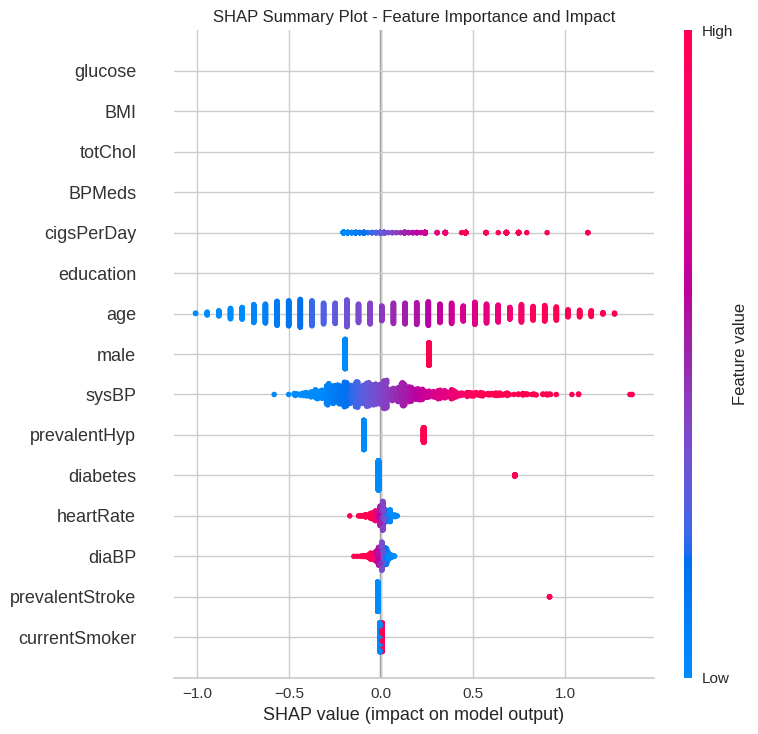


FEATURE IMPORTANCE BAR PLOT


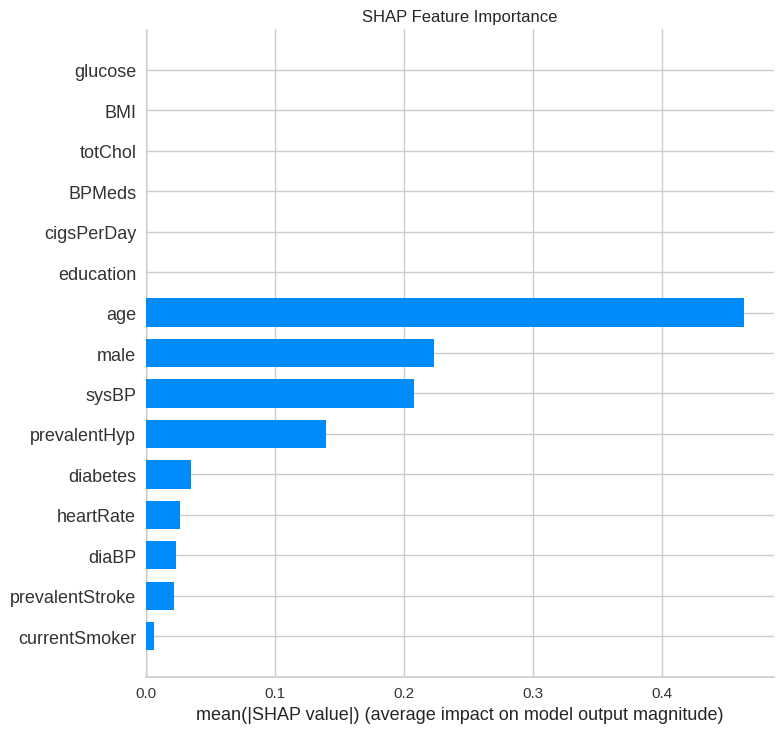


TOP 10 MOST IMPORTANT FEATURES:
age: 0.4640
male: 0.2235
sysBP: 0.2081
prevalentHyp: 0.1399
diabetes: 0.0350
heartRate: 0.0261
diaBP: 0.0229
prevalentStroke: 0.0215
currentSmoker: 0.0058
education: nan


In [17]:
# SHAP FEATURE
print("SHAP SUMMARY PLOT")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Importance and Impact')
plt.tight_layout()
plt.show()

# SHAP Bar Plot
print("\nFEATURE IMPORTANCE BAR PLOT")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

# Calculate feature
feature_importance = np.abs(shap_values).mean(0)
feature_names = X_test.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTOP 10 MOST IMPORTANT FEATURES:")
print("="*50)
for i, row in importance_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

SHAP analysis shows the TOP risk factors very clearly:
TOP 5 MOST IMPORTANT FEATURES:

age: 0.4640 (most important - age)
male: 0.2235 (male gender)
sysBP: 0.2081 (systolic blood pressure)
prevalentHyp: 0.1399 (history of hypertension)
diabetes: 0.0350 (diabetes)

Clinical insights relevant to medicine:

Age is the strongest risk factor
Gender (male) has higher risk
Blood pressure is important
Hypertension history has an impact

In [19]:
# FINAL RESULTS SUMMARY
print("="*80)
print("CORONARY HEART DISEASE PREDICTION - FINAL RESULTS!")
print("="*80)

print("MODEL PERFORMANCE:")
print(f"  • Final AUC: 0.7301")
print(f"  • Accuracy: 66.04%")
print(f"  • Recall: 68.39%")

print(f"\nTOP 5 RISK FACTORS (SHAP Analysis):")
print(f"  1. Age (0.4640) - Most critical factor")
print(f"  2. Male gender (0.2235) - Higher risk in men")
print(f"  3. Systolic BP (0.2081) - Blood pressure impact")
print(f"  4. Hypertension history (0.1399) - Previous BP issues")
print(f"  5. Diabetes (0.0350) - Metabolic factor")

print(f"\nCLINICAL APPLICATIONS:")
print(f"  ✓ Model can assist in CHD risk assessment")
print(f"  ✓ SHAP provides explainable predictions for doctors")
print(f"  ✓ Identifies key modifiable risk factors")
print(f"  ✓ Supports preventive healthcare decisions")

print(f"\nPROJECT COMPLETED!!")


CORONARY HEART DISEASE PREDICTION - FINAL RESULTS!
MODEL PERFORMANCE:
  • Final AUC: 0.7301
  • Accuracy: 66.04%
  • Recall: 68.39%

TOP 5 RISK FACTORS (SHAP Analysis):
  1. Age (0.4640) - Most critical factor
  2. Male gender (0.2235) - Higher risk in men
  3. Systolic BP (0.2081) - Blood pressure impact
  4. Hypertension history (0.1399) - Previous BP issues
  5. Diabetes (0.0350) - Metabolic factor

CLINICAL APPLICATIONS:
  ✓ Model can assist in CHD risk assessment
  ✓ SHAP provides explainable predictions for doctors
  ✓ Identifies key modifiable risk factors
  ✓ Supports preventive healthcare decisions

PROJECT COMPLETED!!
